# Verify sector ETF betas
Load the saved regression statistics and the time-weighted return section from each stagger sheet.

In [1]:
%pip install -q matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file = Path("data/companies_and_staggered_returns.xlsx")
sectors = ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]
stagger_names = [f"stagger_{i}" for i in range(1, 5)]

betas = pd.read_excel(file, sheet_name="Regression Stats")

# Skip the earlier sections; row 255 is the time-weighted-return header.
weighted_returns = {
    stagger: pd.read_excel(
        file, sheet_name=stagger, skiprows=254, nrows=80, parse_dates=["date"]
    ).set_index("date")
    for stagger in stagger_names
}

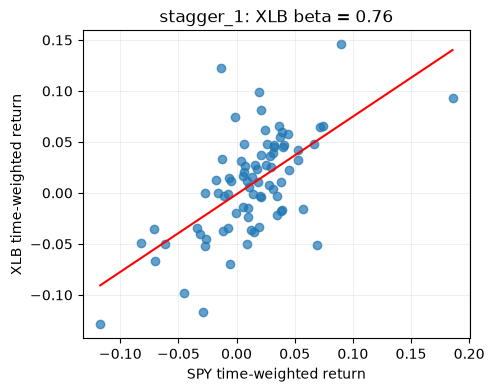

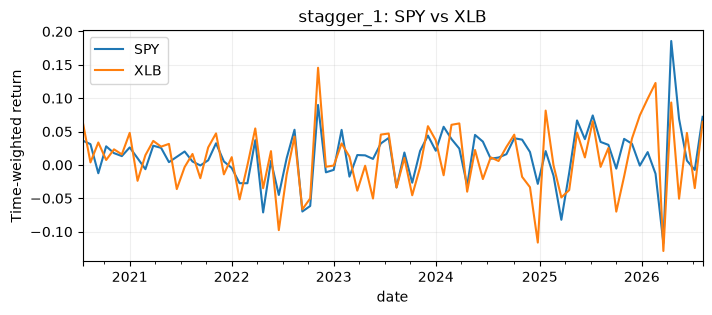

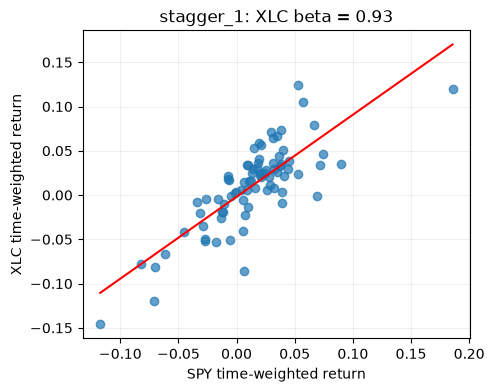

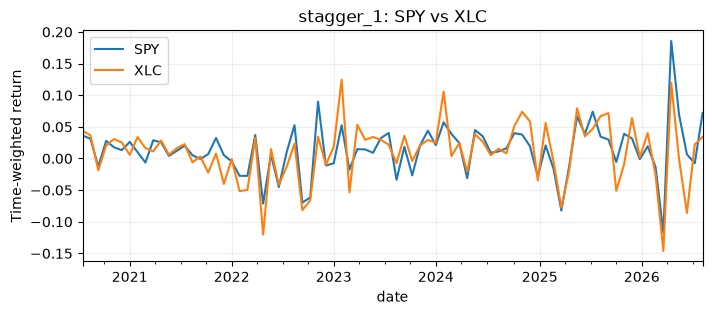

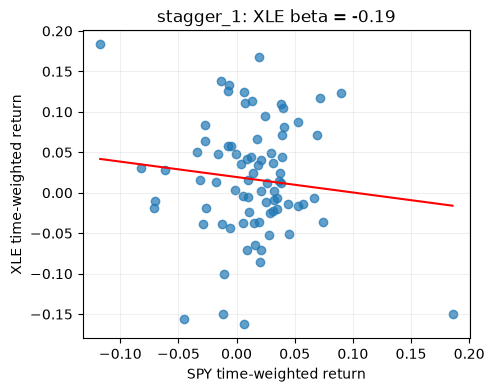

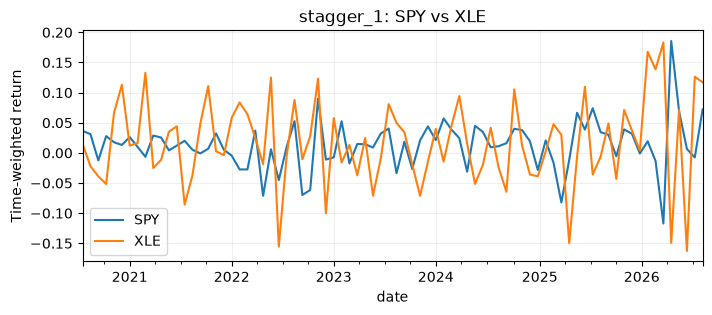

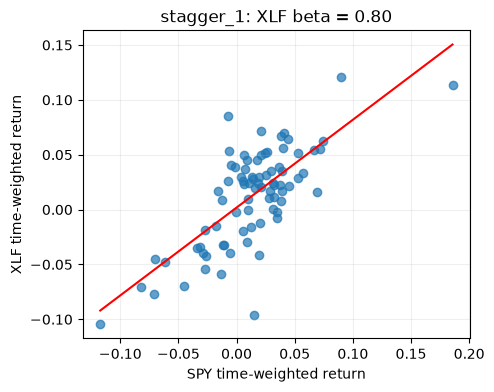

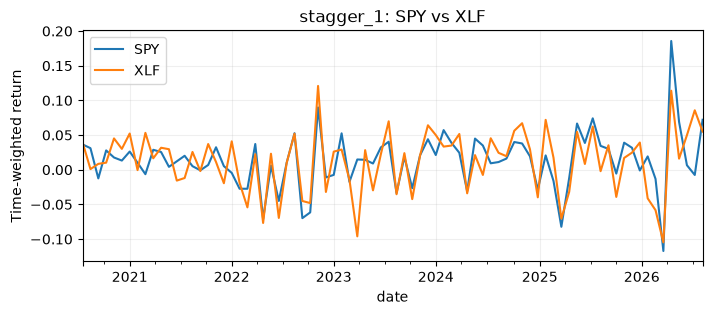

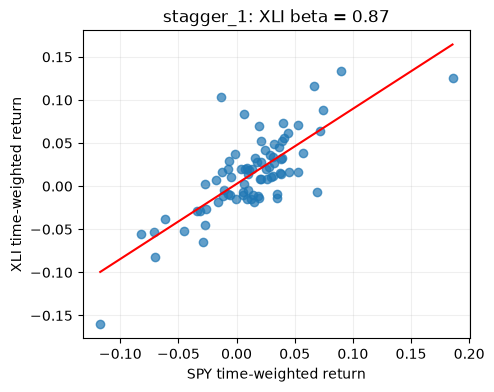

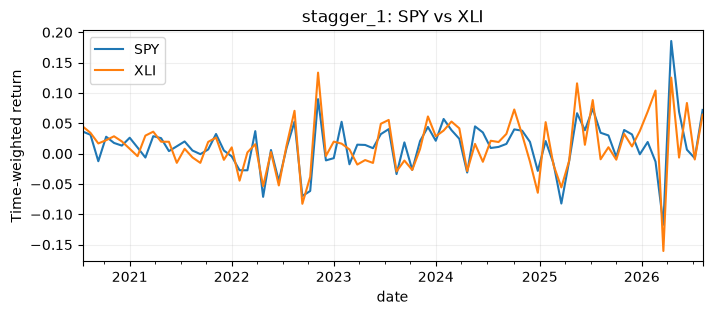

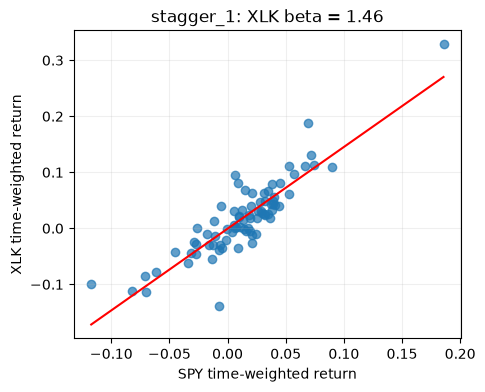

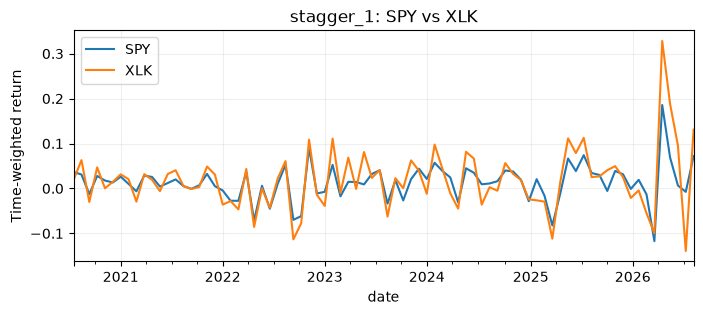

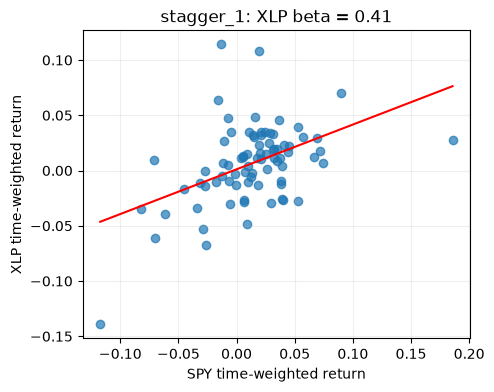

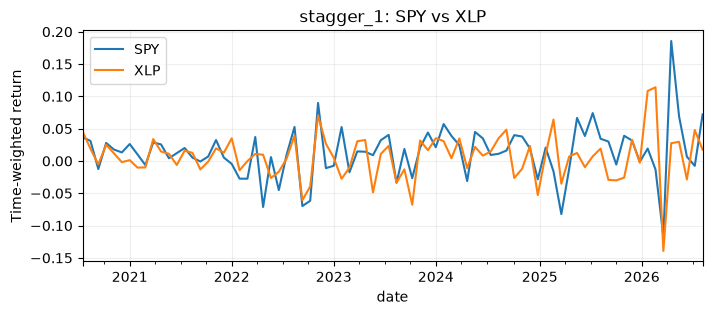

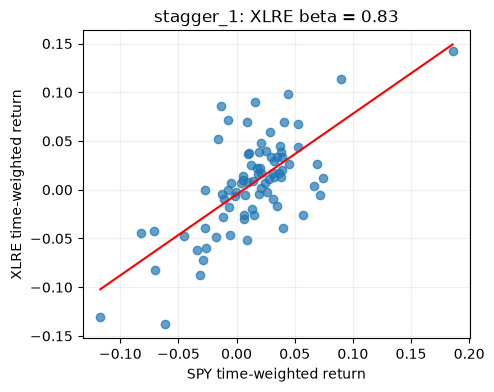

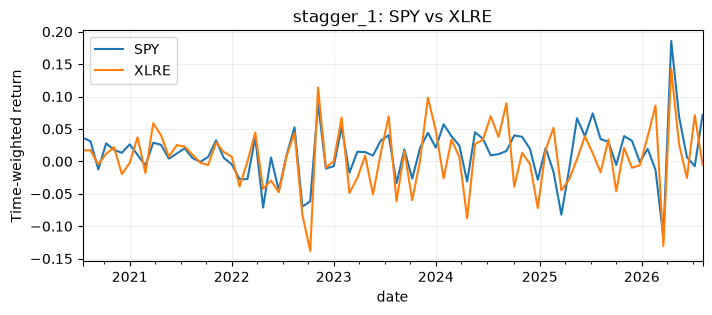

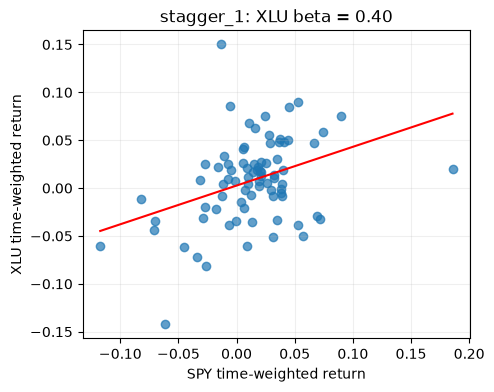

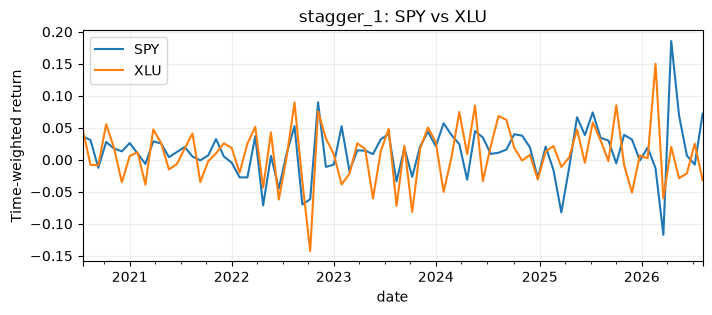

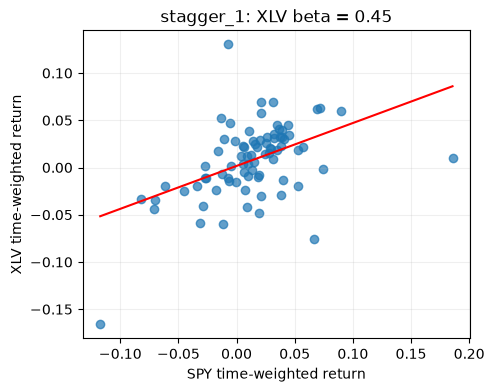

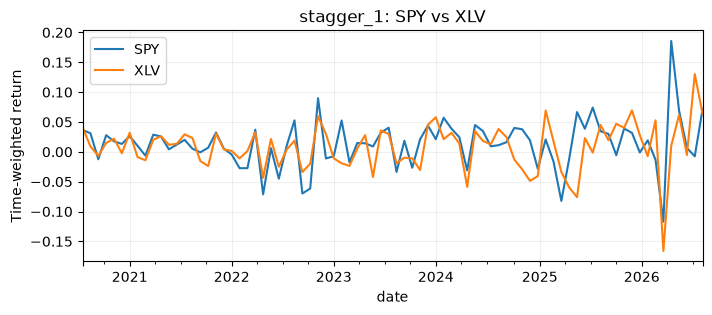

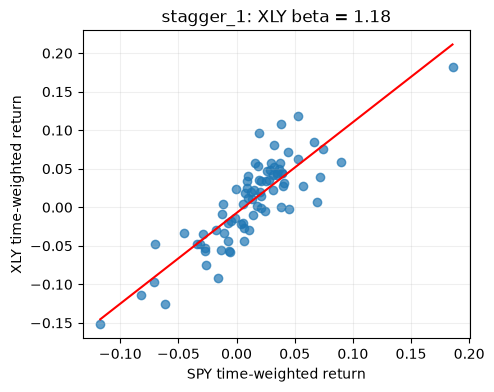

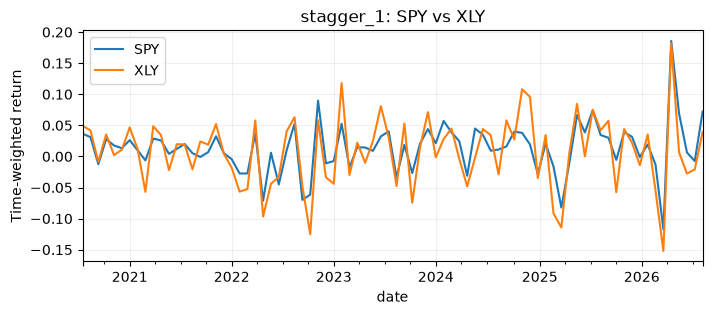

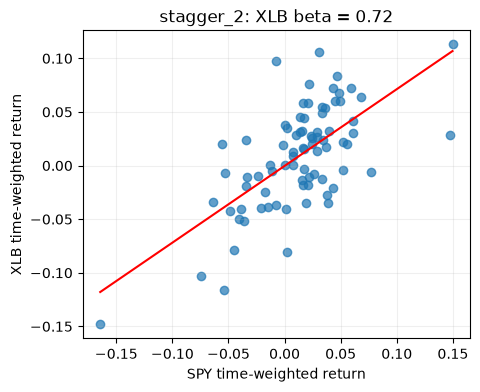

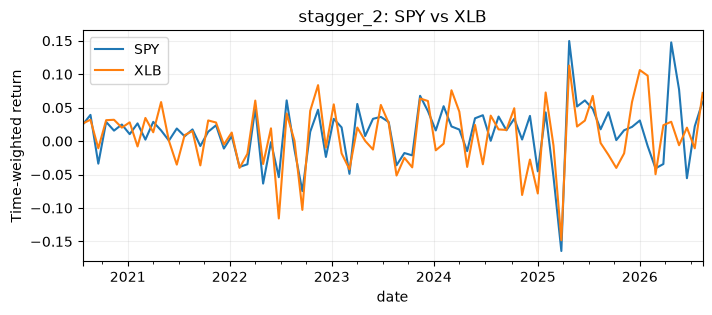

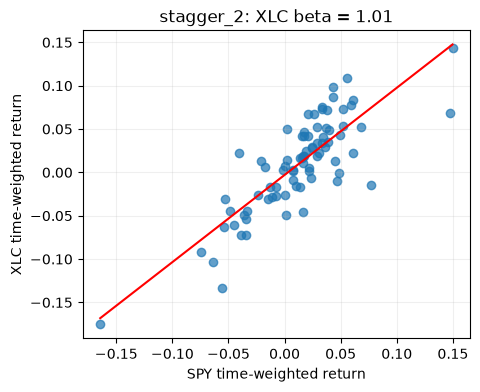

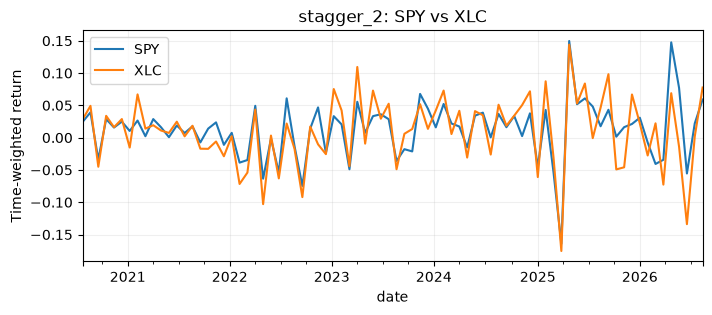

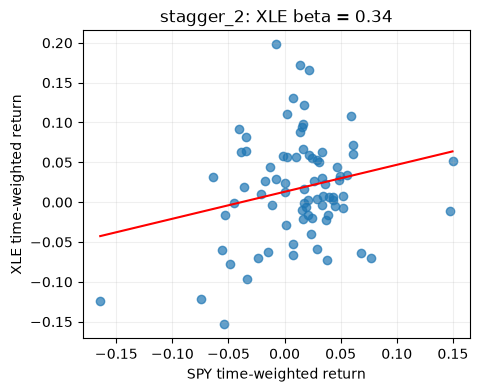

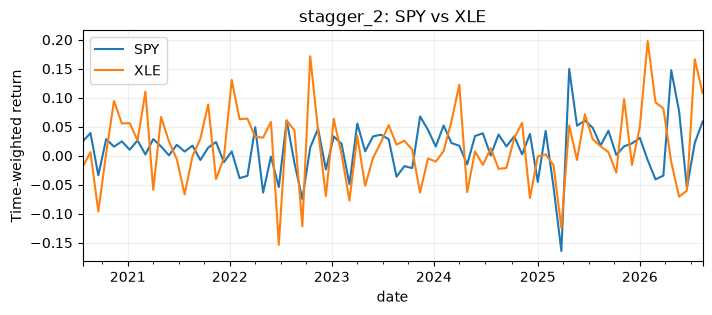

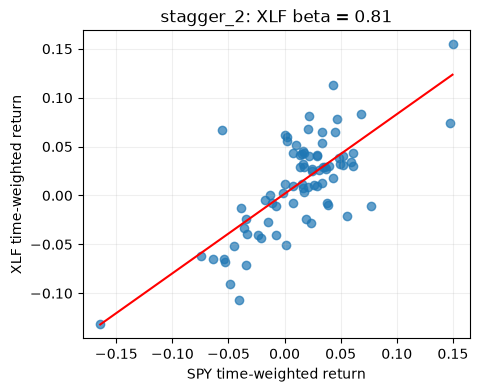

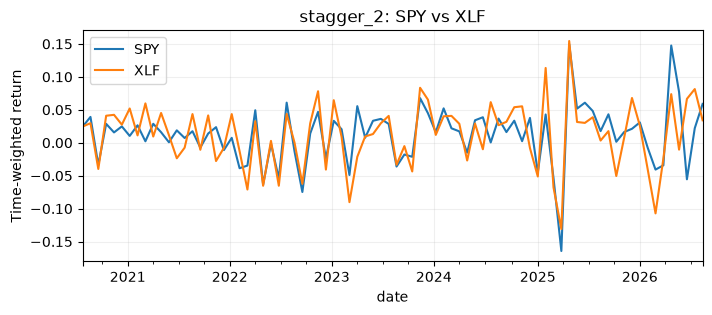

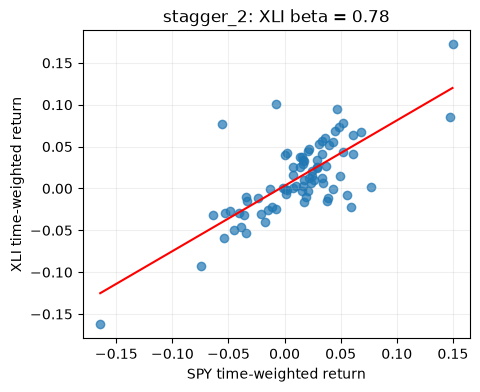

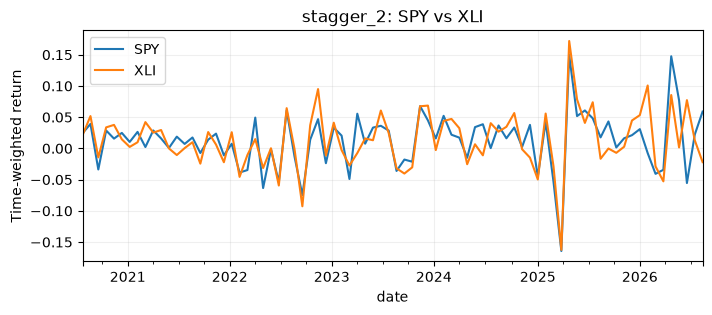

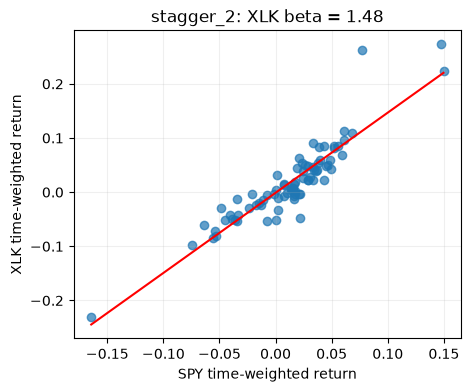

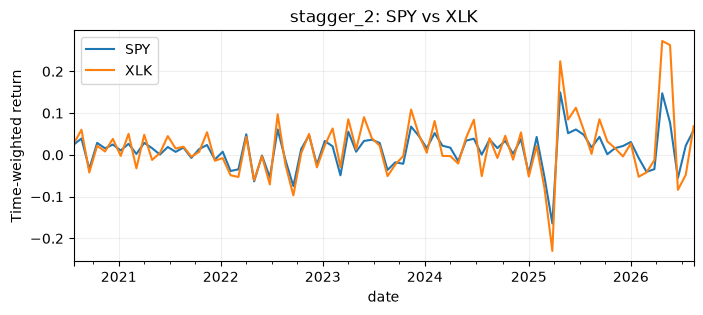

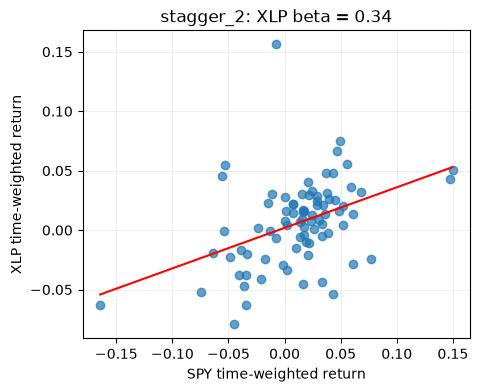

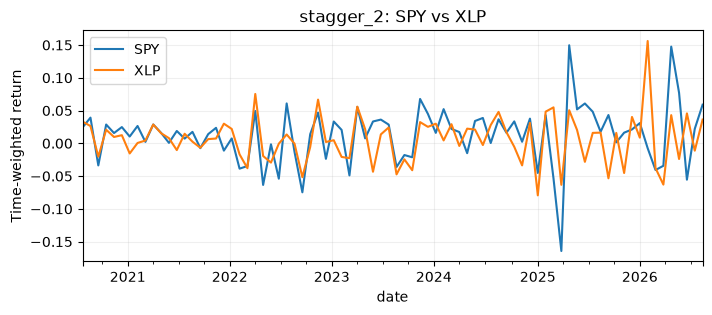

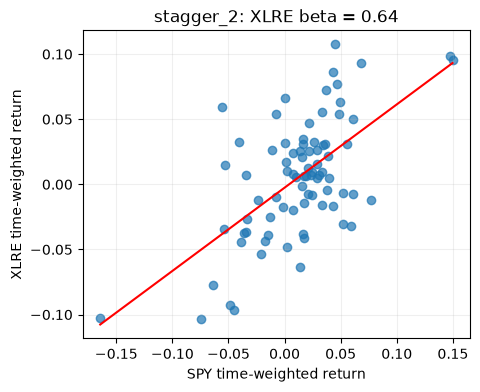

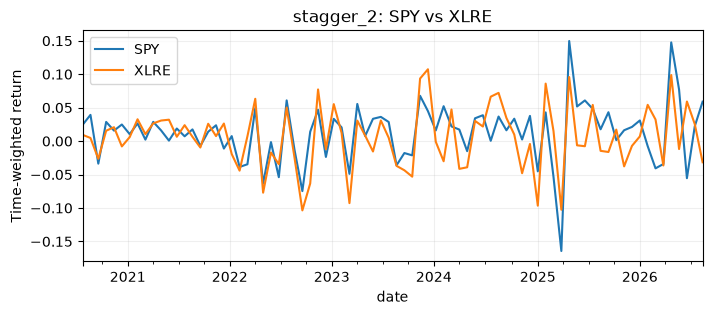

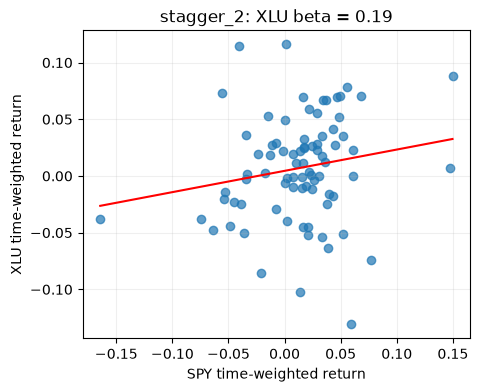

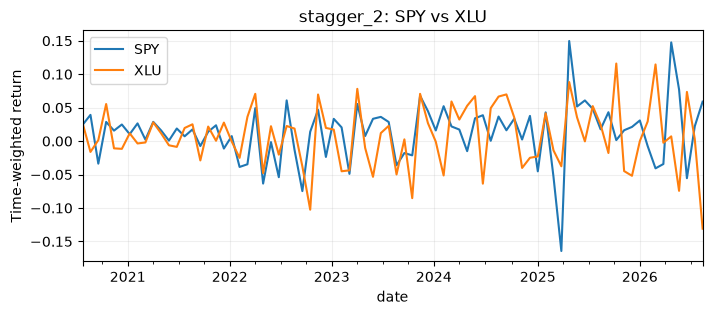

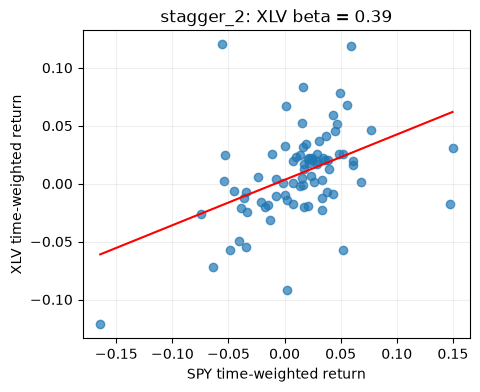

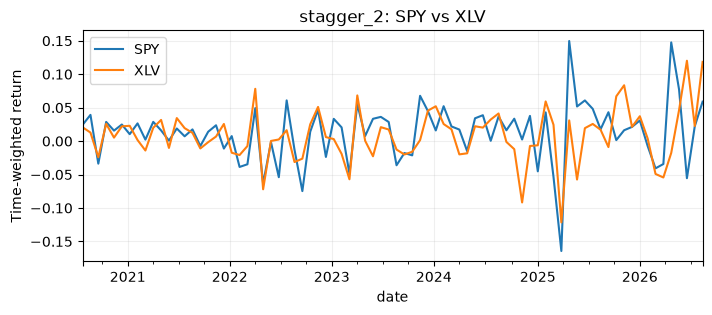

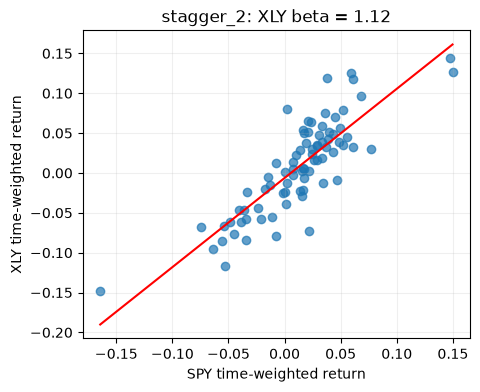

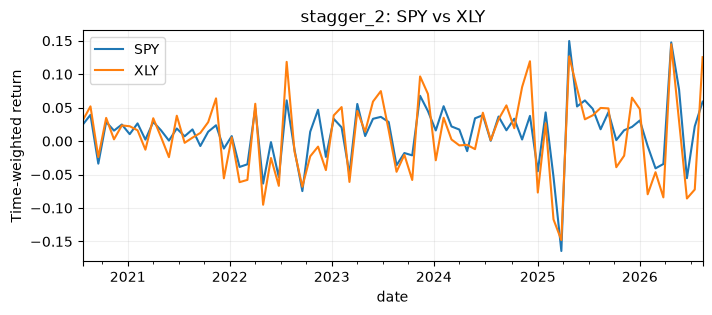

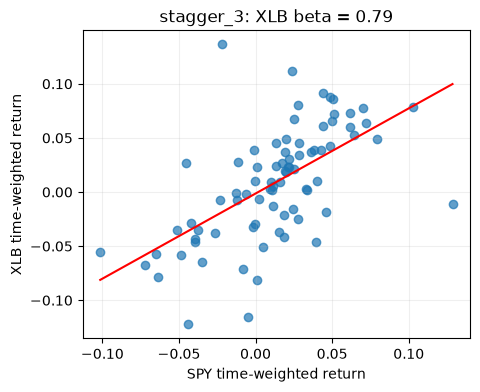

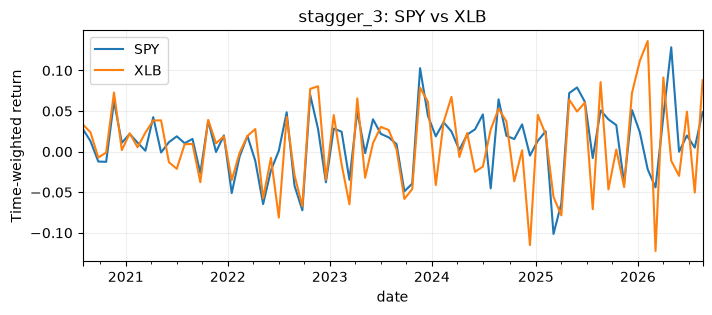

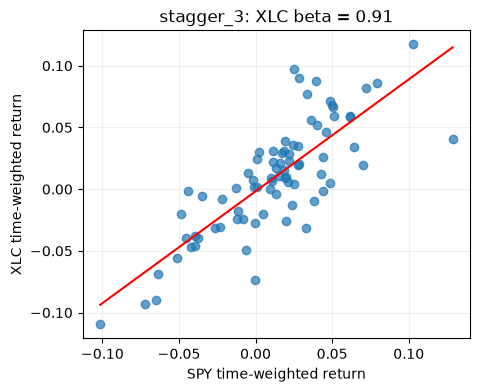

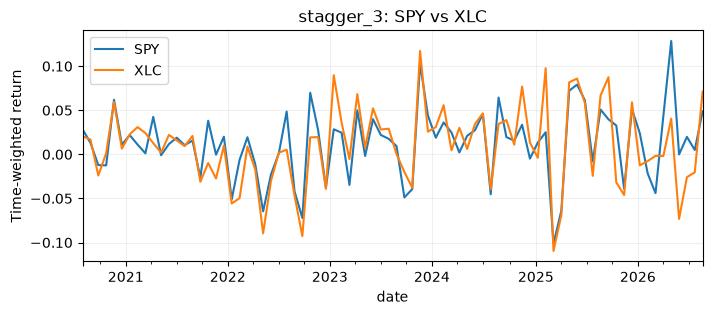

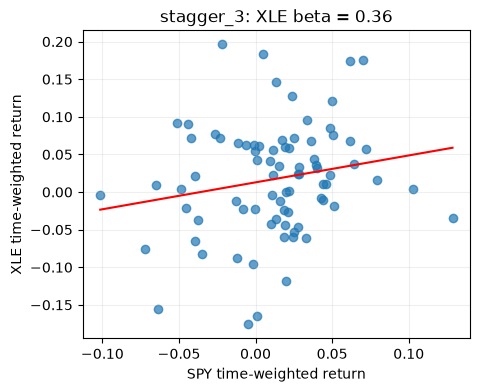

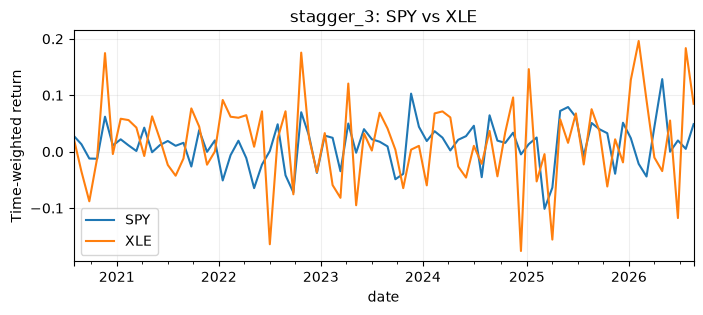

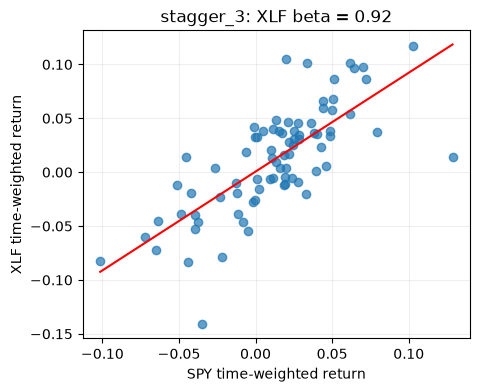

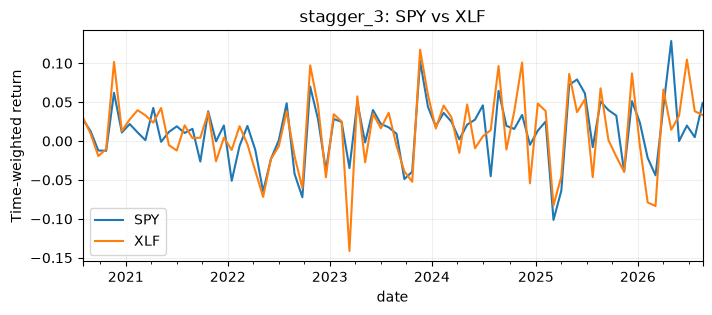

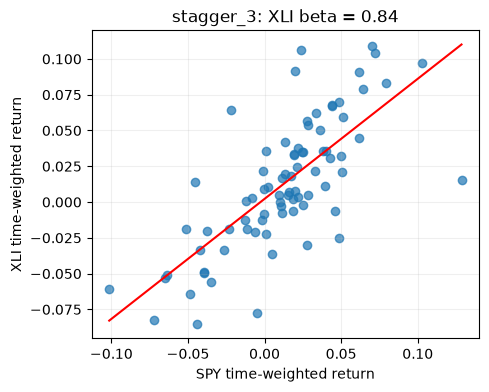

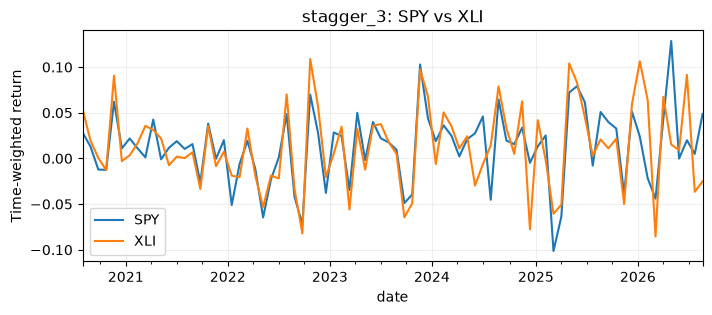

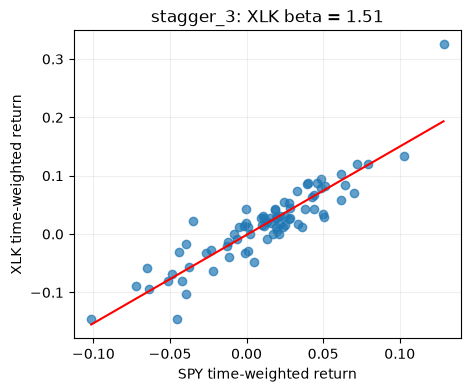

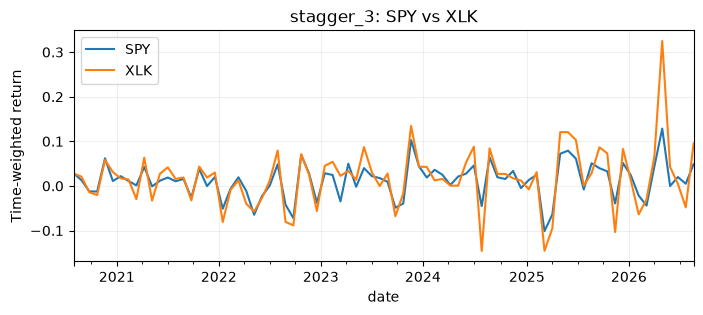

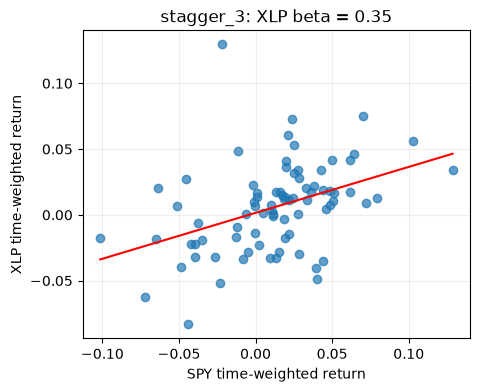

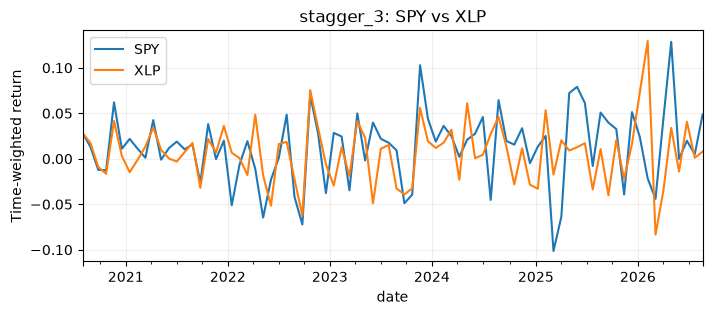

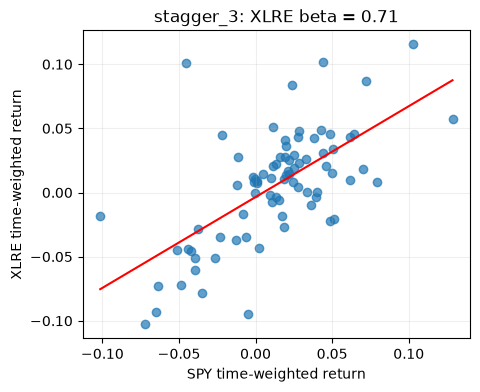

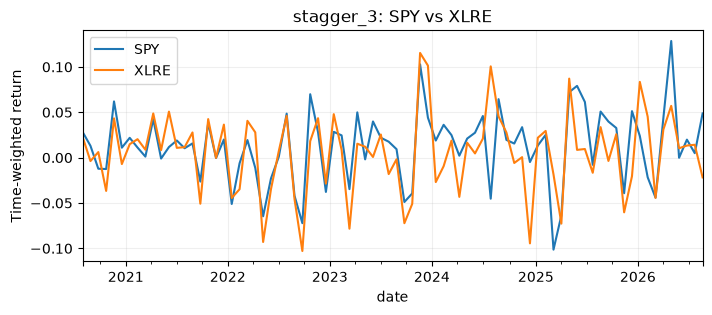

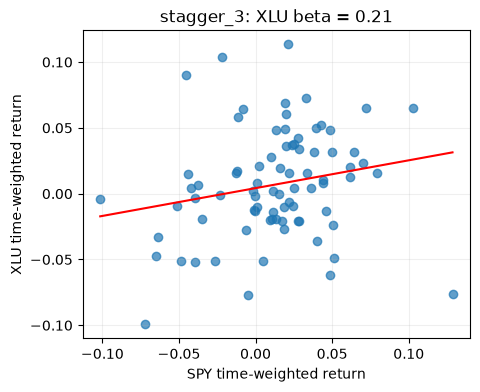

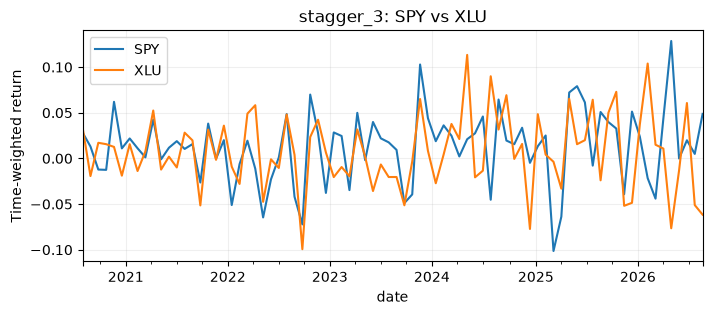

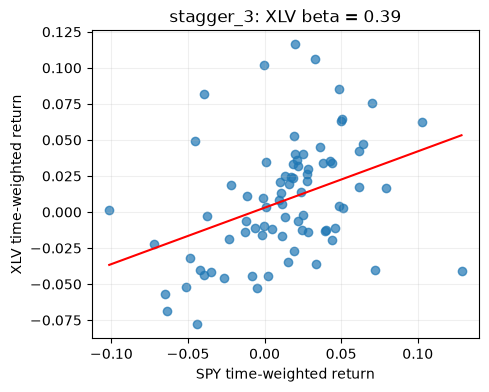

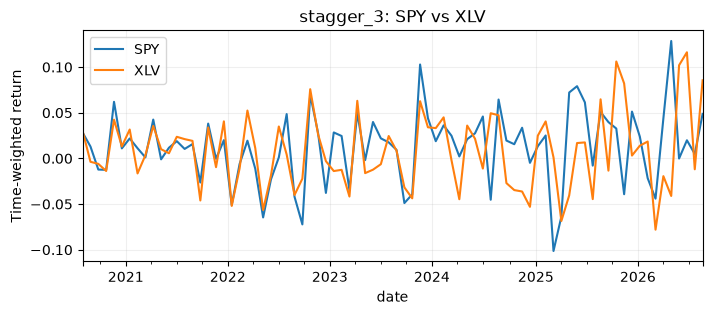

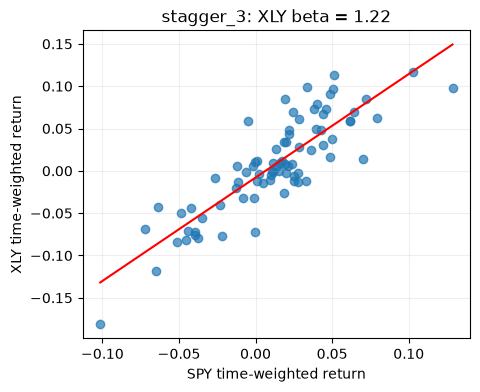

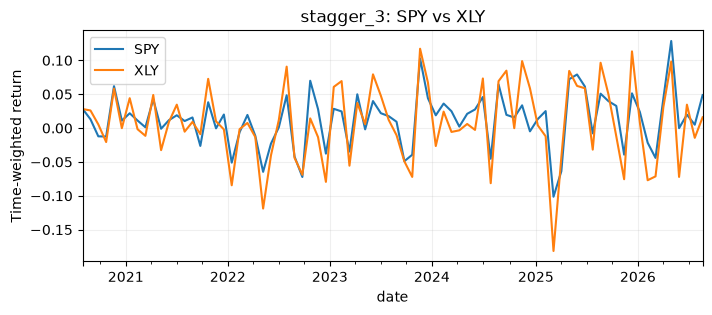

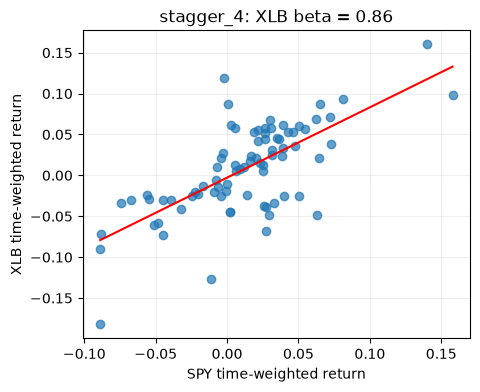

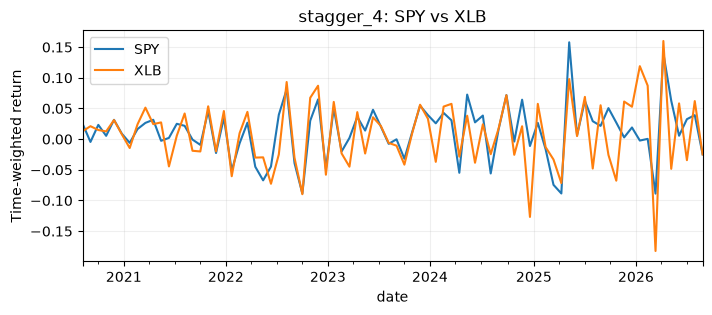

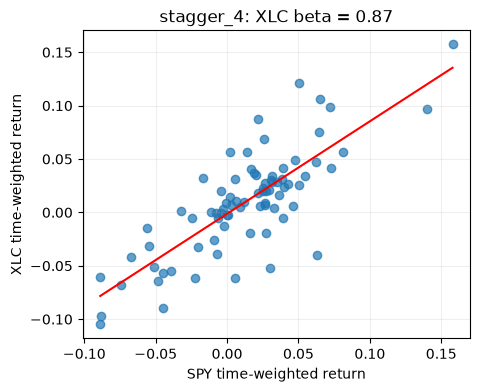

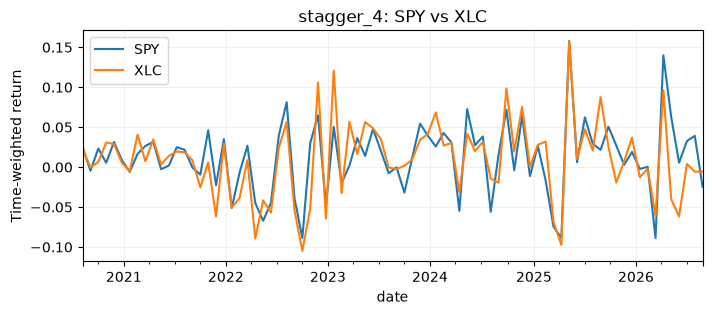

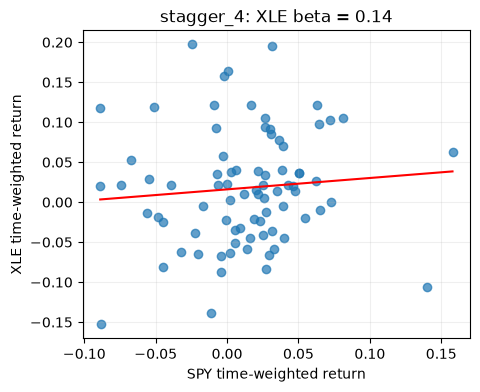

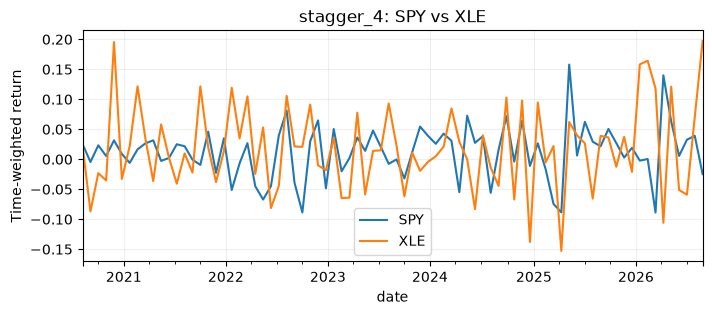

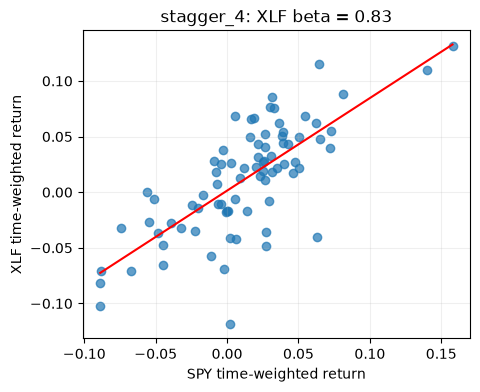

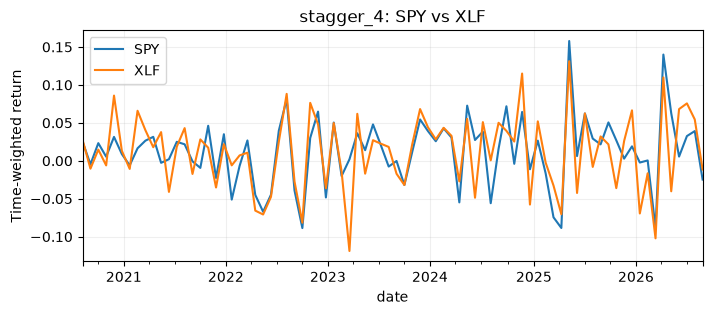

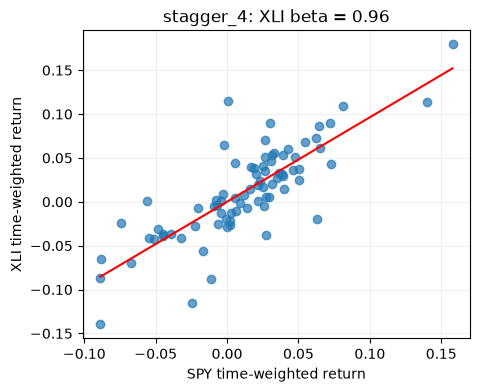

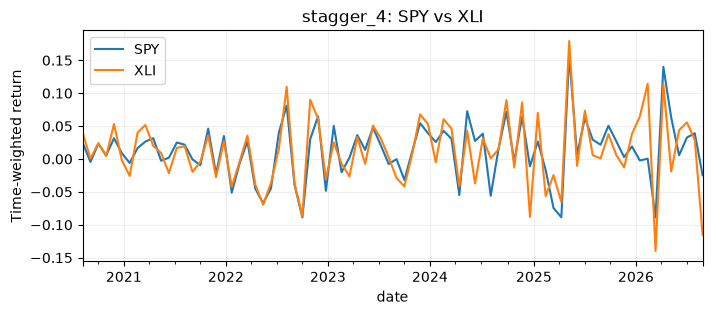

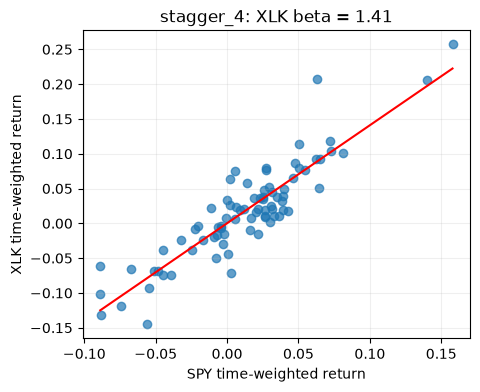

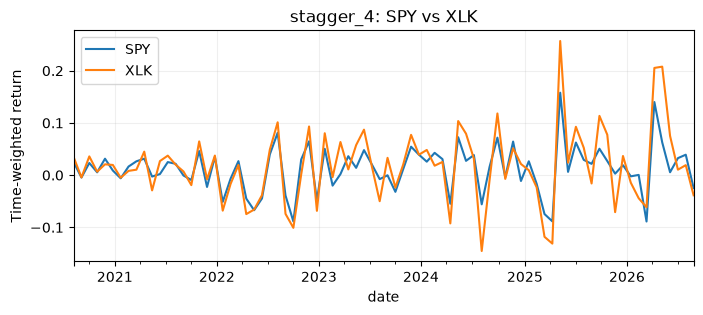

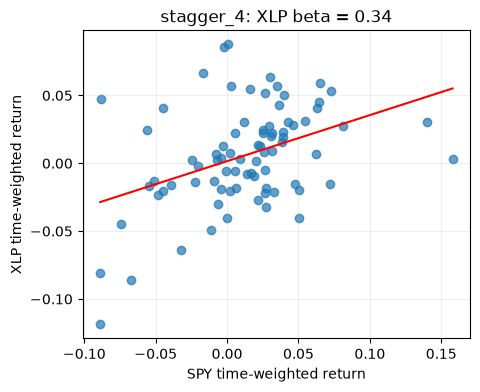

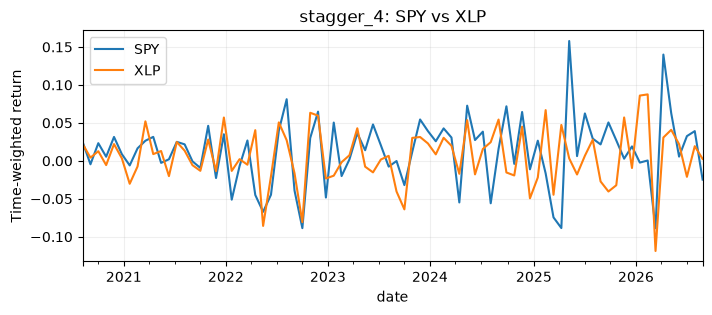

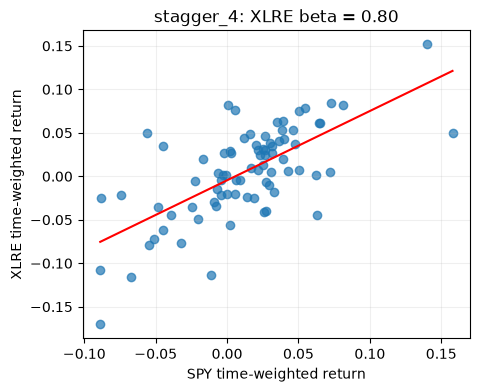

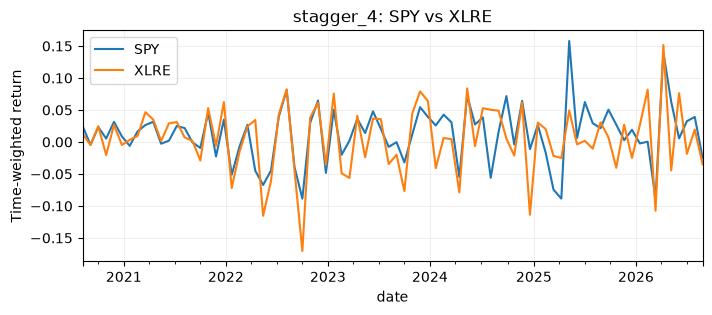

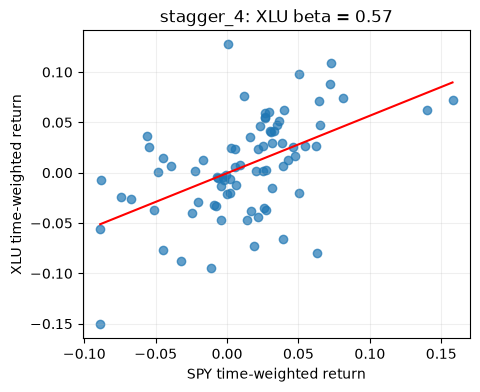

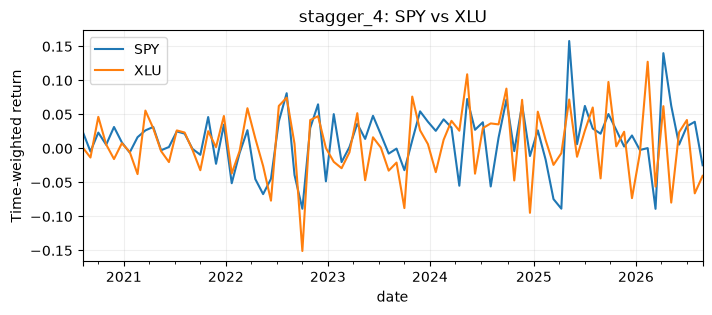

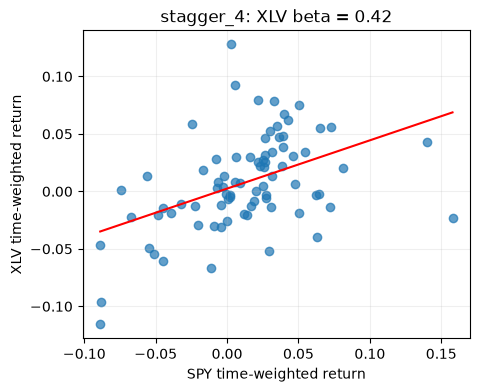

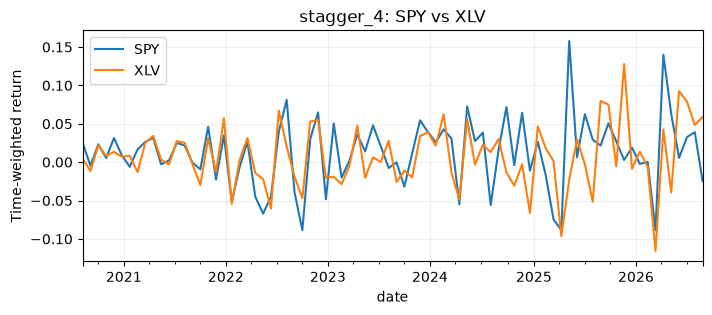

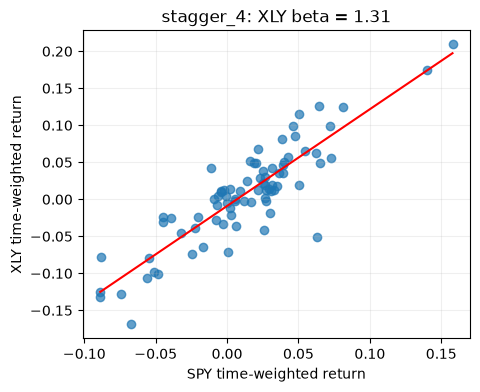

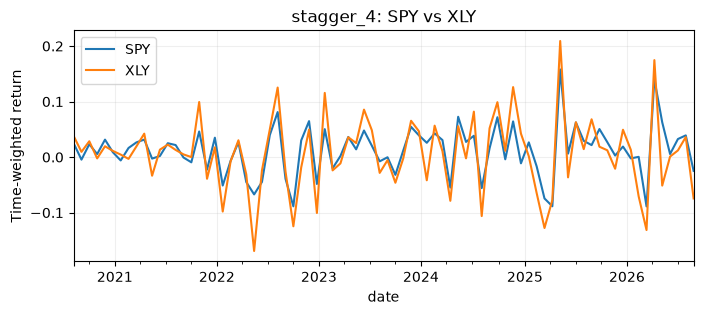

In [4]:
for stagger, returns in weighted_returns.items():
    for sector in sectors:
        stats = betas.query("stagger == @stagger and sector == @sector").iloc[0]
        x, y = returns["SPY"], returns[sector]
        line_x = np.linspace(x.min(), x.max(), 100)

        plt.figure(figsize=(5, 4))
        plt.scatter(x, y, alpha=.7)
        plt.plot(line_x, stats["alpha"] + stats["beta"] * line_x, color="red")
        plt.title(f"{stagger}: {sector} beta = {stats['beta']:.2f}")
        plt.xlabel("SPY time-weighted return")
        plt.ylabel(f"{sector} time-weighted return")
        plt.grid(alpha=.2)
        plt.show()

        returns[["SPY", sector]].plot(figsize=(8, 3), title=f"{stagger}: SPY vs {sector}")
        plt.ylabel("Time-weighted return")
        plt.grid(alpha=.2)
        plt.show()